# Reach direction and velocity tuning in macaque motor cortex

This notebook demonstrates the two classic tuning properties of primate motor
cortex during reaching, using only real data streamed from the DANDI Archive:

1. **Direction tuning.** A motor cortical neuron fires most strongly for
   reaches in one preferred direction and its rate falls off roughly as the
   cosine of the angle away from it (Georgopoulos et al. 1982).
2. **Velocity tuning.** The directional modulation is not all-or-none: its
   amplitude scales with hand speed, so the rate tracks the full velocity
   *vector* rather than direction alone (Schwartz 1994, Moran & Schwartz 1999).
   Motor cortical activity leads the hand by tens of milliseconds.

## Data

Six sessions from three experiments released through the Neural Latents
Benchmark, all streamed with `remfile` + a local disk cache (no full
downloads):

| dandiset | experiment | subject | area | task |
|---|---|---|---|---|
| [000128](https://dandiarchive.org/dandiset/000128) | MC_Maze (full) | Jenkins | M1 + PMd | delayed center-out and maze reaching |
| [000138](https://dandiarchive.org/dandiset/000138) | MC_Maze (large) | Jenkins | M1 + PMd | same task, 2009-10-06 |
| [000139](https://dandiarchive.org/dandiset/000139) | MC_Maze (medium) | Jenkins | M1 + PMd | same task, 2009-09-29 |
| [000140](https://dandiarchive.org/dandiset/000140) | MC_Maze (small) | Jenkins | M1 + PMd | same task, 2009-09-28 |
| [000129](https://dandiarchive.org/dandiset/000129) | MC_RTT | Indy | M1 | self-paced random-target reaching |
| [000127](https://dandiarchive.org/dandiset/000127) | Area2_Bump | Han | somatosensory area 2 | center-out with mechanical bumps |

Area 2 is included deliberately as a control: it carries proprioceptive
feedback, so if the lead-time analysis is measuring anything real, area 2
should *follow* the hand where motor cortex leads it.

Two helper modules live alongside this notebook: `dandi_io.py` (streaming and
caching) and `analysis.py` (the tuning computations).  Everything else is
inline below.

In [1]:
import matplotlib
matplotlib.use("Agg")           # this notebook is meant to run headless
import matplotlib.pyplot as plt
import numpy as np
import nemos as nmo
import pynapple as nap
from sklearn.linear_model import Ridge
from tqdm.auto import tqdm

import analysis as an
import dandi_io as dio

plt.rcParams.update({"axes.titlesize": 10, "axes.labelsize": 9,
                     "xtick.labelsize": 8, "ytick.labelsize": 8,
                     "figure.dpi": 110})
np.set_printoptions(precision=3, suppress=True)


def save_show(fig, path, **kwargs):
    """Write the figure to disk and, inside Jupyter, show the saved PNG.

    The Agg backend never opens a window, so nothing here can block a headless
    run; the notebook simply embeds the file that was just written.
    """
    fig.savefig(path, dpi=150, **kwargs)
    plt.close(fig)
    try:
        get_ipython()                      # noqa: F821  (defined only in IPython)
        from IPython.display import Image, display
        display(Image(filename=path))
    except NameError:
        pass

## 1. Load one session and check every data stream

`dandi_io.load_session` resolves the DANDI asset to its S3 URL, streams the
NWB file, and pulls out spike times, the trial table and the 1 kHz hand
kinematics.  Kinematics are converted to mm and mm/s using each file's own
NWB conversion factor, because the three experiments stored them on different
scales.  The arrays are cached to a local `.npz` so re-running is fast.

In [2]:
sess = dio.load_session("maze_full")
spikes, pos, vel, support = dio.to_pynapple(sess)
tr = sess["trials"]

print(sess["session_label"], "| monkey", sess["monkey"])
print("units:", len(spikes), " trials:", len(tr["start_time"]))
print("behaviour: %d contiguous segments, %.0f s total"
      % (len(support), support.tot_length()))
speed_all = np.linalg.norm(vel.values, axis=1)
print("hand speed (mm/s): median %.0f, 99th pct %.0f"
      % (np.median(speed_all), np.percentile(speed_all, 99)))
print("firing rate (Hz): min %.2f, median %.2f, max %.2f"
      % (spikes.rates.min(), np.median(np.asarray(spikes.rates)), spikes.rates.max()))

MC_Maze full (Jenkins 2009-09-25) | monkey Jenkins
units: 182  trials: 2295
behaviour: 2295 contiguous segments, 6808 s total


hand speed (mm/s): median 5, 99th pct 802
firing rate (Hz): min 0.12, median 1.68, max 15.46


A note on unit locations: the NWB files list both an M1 and a PMd electrode
group, but every sorted unit in the MC_Maze conversion points at a row in the
first (PMd) block of the electrode table, so the array of origin is not
actually recoverable from the file.  Units are therefore treated as one
motor cortical population throughout and no M1-versus-PMd split is attempted.

In [3]:
print("electrode-group label attached to units:",
      {a: int((sess["unit_area"] == a).sum()) for a in np.unique(sess["unit_area"])})

electrode-group label attached to units: {np.str_('PMd'): 182}


### Figure 1: raw data quality control

Before any analysis, look at the hand paths, the speed profiles, the velocity
traces and the spikes.  Barrier-free trials should be straight radial reaches;
maze trials should curve around the barriers; speed profiles should be
bell-shaped and peak roughly 120 ms after the recorded movement onset.

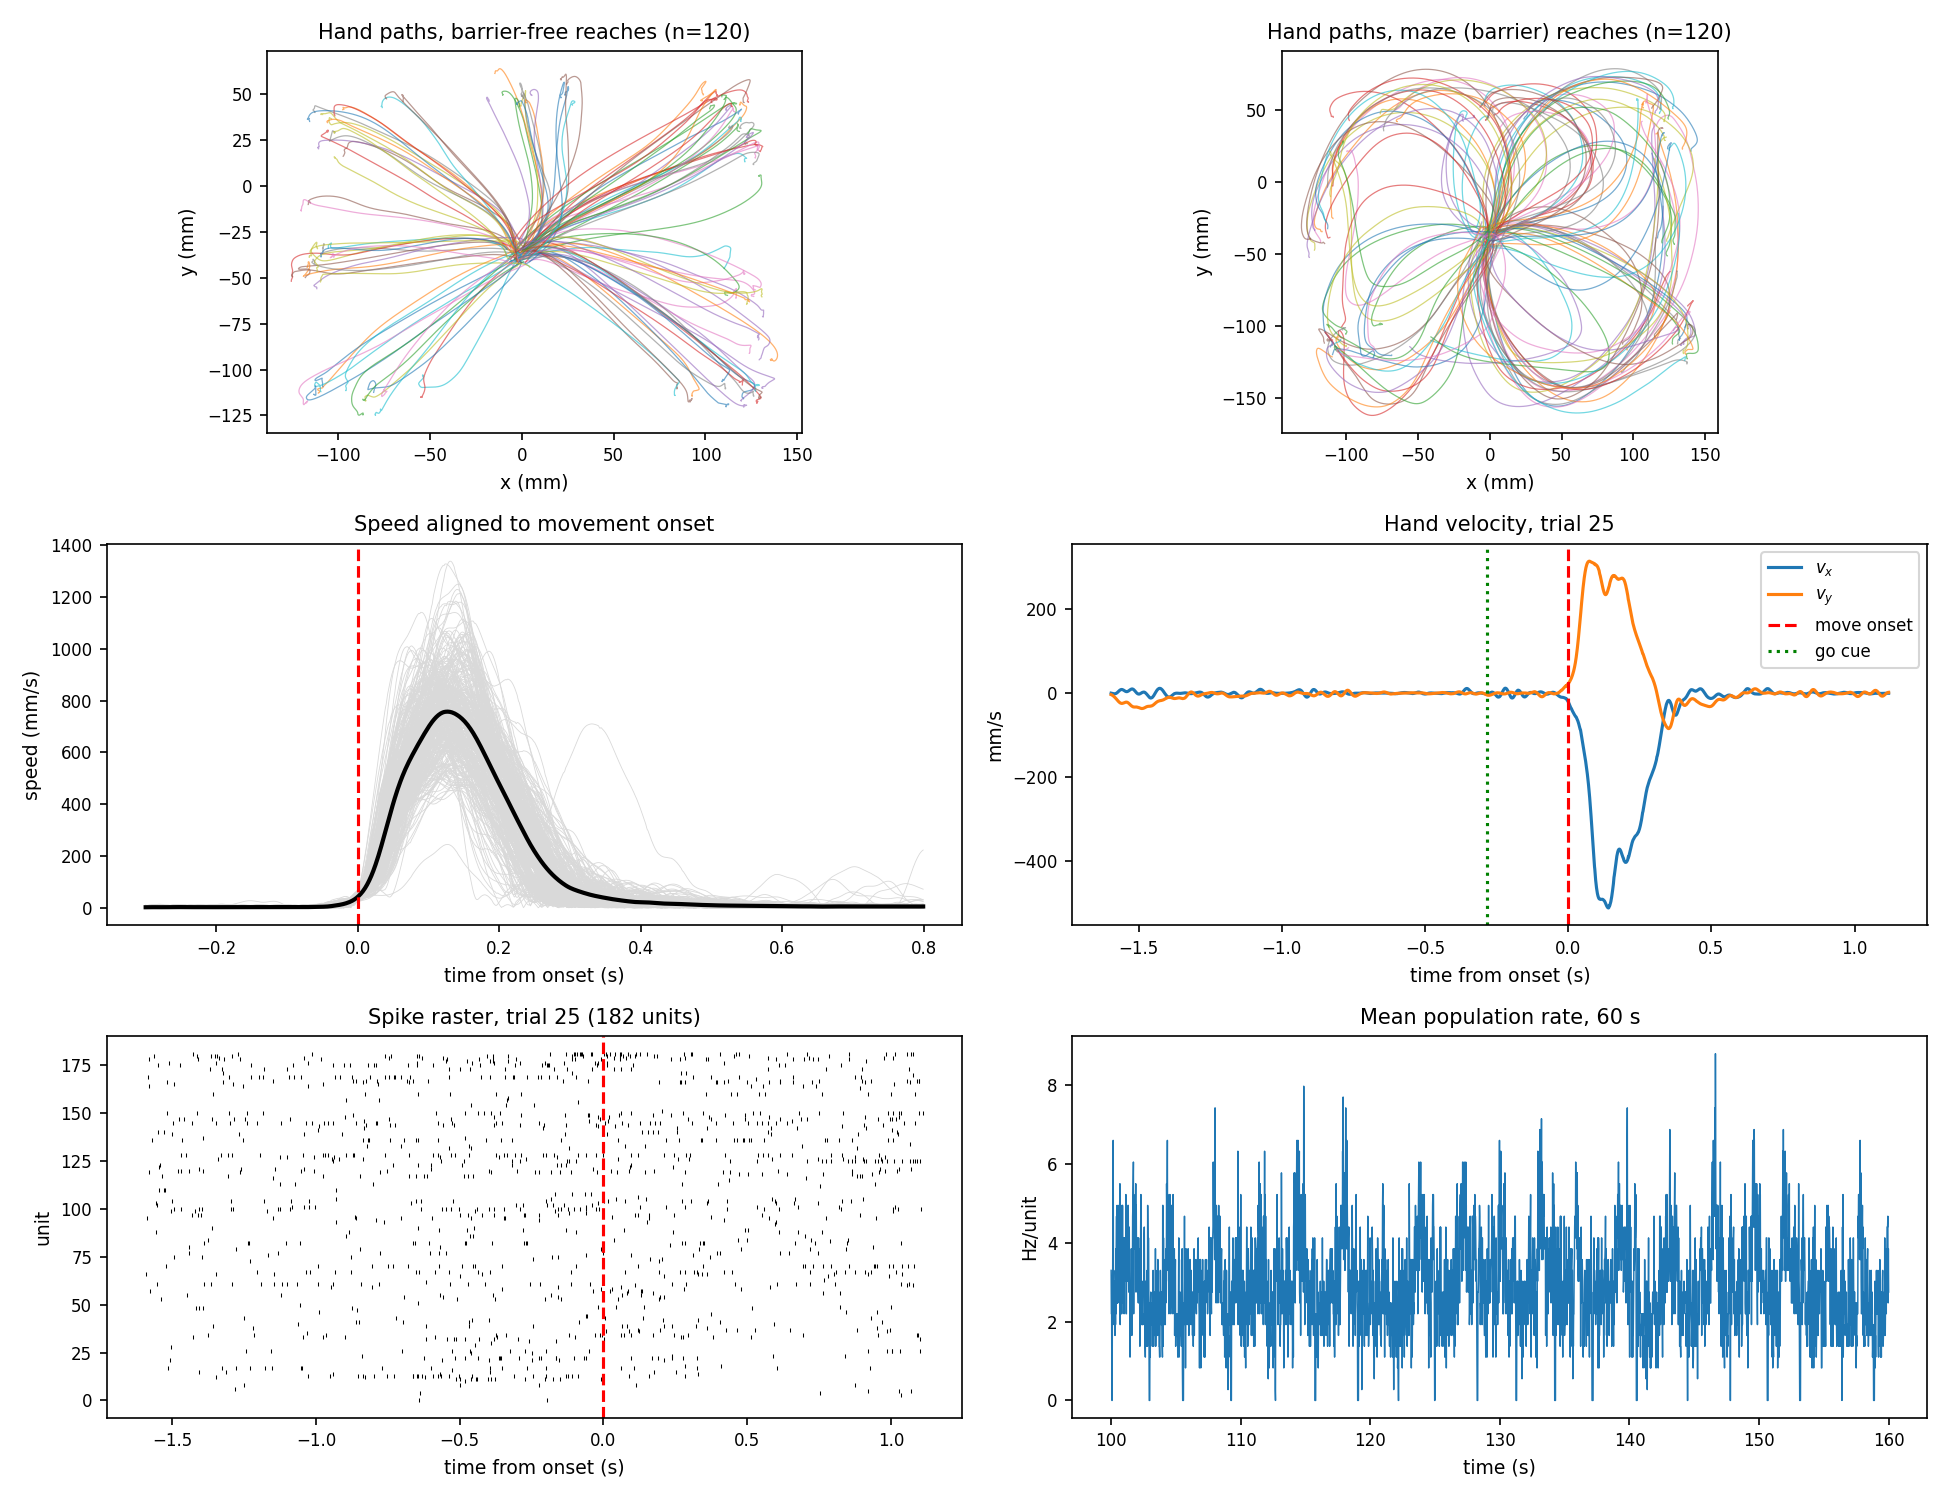

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(13, 10))

straight = np.flatnonzero(tr["num_barriers"] == 0)
curved = np.flatnonzero(tr["num_barriers"] > 0)
for ax, idx_, title in [(axes[0, 0], straight[:120], "barrier-free reaches"),
                        (axes[0, 1], curved[:120], "maze (barrier) reaches")]:
    for i in idx_:
        seg = pos.restrict(nap.IntervalSet(tr["move_onset_time"][i],
                                           tr["move_onset_time"][i] + 0.6))
        ax.plot(seg.values[:, 0], seg.values[:, 1], lw=0.6, alpha=0.6)
    ax.set(title=f"Hand paths, {title} (n={len(idx_)})", xlabel="x (mm)",
           ylabel="y (mm)")
    ax.set_aspect("equal")

ax = axes[1, 0]
lag = np.arange(-0.3, 0.8, 0.001)
prof = np.array([np.interp(tr["move_onset_time"][i] + lag, pos.index.values, speed_all)
                 for i in straight[:300]])
ax.plot(lag, prof.T, color="0.85", lw=0.4)
ax.plot(lag, prof.mean(0), "k", lw=2)
ax.axvline(0, color="r", ls="--")
ax.set(title="Speed aligned to movement onset", xlabel="time from onset (s)",
       ylabel="speed (mm/s)")

i = straight[5]
ep_i = nap.IntervalSet(tr["start_time"][i], tr["stop_time"][i])
ax = axes[1, 1]
v_i = vel.restrict(ep_i)
ax.plot(v_i.index.values - tr["move_onset_time"][i], v_i.values[:, 0], label="$v_x$")
ax.plot(v_i.index.values - tr["move_onset_time"][i], v_i.values[:, 1], label="$v_y$")
ax.axvline(0, color="r", ls="--", label="move onset")
ax.axvline(tr["go_cue_time"][i] - tr["move_onset_time"][i], color="g", ls=":",
           label="go cue")
ax.legend(fontsize=8)
ax.set(title=f"Hand velocity, trial {i}", xlabel="time from onset (s)",
       ylabel="mm/s")

ax = axes[2, 0]
for u in range(len(spikes)):
    s_ = spikes[u].restrict(ep_i).index.values - tr["move_onset_time"][i]
    ax.plot(s_, np.full_like(s_, u), "|", color="k", ms=2, mew=0.5)
ax.axvline(0, color="r", ls="--")
ax.set(title=f"Spike raster, trial {i} ({len(spikes)} units)",
       xlabel="time from onset (s)", ylabel="unit")

ax = axes[2, 1]
cnt = spikes.count(0.02, nap.IntervalSet(100, 160))
ax.plot(cnt.index.values, cnt.values.sum(1) / 0.02 / len(spikes), lw=0.7)
ax.set(title="Mean population rate, 60 s", xlabel="time (s)", ylabel="Hz/unit")

fig.tight_layout()
save_show(fig, "fig01_raw_data_qc.png")

## 2. Direction tuning

Only barrier-free trials are used here, so that the reach is a straight
center-out movement with a single well-defined direction.  The direction of
each reach is taken from the hand displacement over the 300 ms after movement
onset rather than from the nominal target, so it reflects what the arm
actually did.

Rather than binning trials into eight groups and fitting the bin means, each
unit's single-trial rate over the movement window is regressed directly on
`cos(theta)` and `sin(theta)`.  This uses the full spread of directions
(the monkey reached to 35 distinct target positions) and gives a preferred
direction, a modulation depth and an R^2 in one step.  Significance comes
from a permutation test on the modulation depth.

In [5]:
idx = an.straight_trials(sess)
theta, dist = an.reach_direction(sess, idx)
on = tr["move_onset_time"][idx]
keep = an.quality_units(spikes, dio.trial_intervals(sess), min_rate=0.5)
uid = np.flatnonzero(keep)
print(f"{len(idx)} straight reaches, displacement {dist.mean():.0f} +- {dist.std():.0f} mm")
print(f"{keep.sum()} of {len(spikes)} units fire at least 0.5 Hz and are kept")

rates_mov, _ = an.epoch_rates(spikes, on + an.MOVE_WIN[0], on + an.MOVE_WIN[1])
rates_mov = rates_mov[:, keep]
fit_mov = an.fit_cosine_tuning(rates_mov, theta)
sig_mov = fit_mov["p_perm"] < 0.01
print(f"movement epoch (0-350 ms): {sig_mov.sum()}/{len(sig_mov)} units tuned "
      f"(permutation p < 0.01), median R2 {np.nanmedian(fit_mov['r2'][sig_mov]):.3f}, "
      f"max {np.nanmax(fit_mov['r2']):.3f}")

pd_sd = an.bootstrap_pd(rates_mov, theta)
print(f"bootstrap s.d. of the preferred direction: median "
      f"{np.degrees(np.median(pd_sd[sig_mov])):.1f} deg")

R = np.abs(np.exp(1j * fit_mov["pd"][sig_mov]).mean())
n_sig = int(sig_mov.sum())
rayleigh_p = np.exp(np.sqrt(1 + 4 * n_sig + 4 * n_sig ** 2 * (1 - R ** 2)) - (1 + 2 * n_sig))
print(f"preferred directions: resultant length R = {R:.3f}, Rayleigh p = {rayleigh_p:.3g}")

789 straight reaches, displacement 124 +- 20 mm
150 of 182 units fire at least 0.5 Hz and are kept


movement epoch (0-350 ms): 130/150 units tuned (permutation p < 0.01), median R2 0.107, max 0.585


bootstrap s.d. of the preferred direction: median 6.0 deg
preferred directions: resultant length R = 0.161, Rayleigh p = 0.0339


### Delay-period tuning, and a control for it

The maze task has an instructed delay, so the same regression can be run on
the interval between target onset and the go cue, before the arm moves.  Most
units are also directionally tuned during that interval.  Whether the delay
preferred direction matches the movement preferred direction is a separate
question, and it needs a control: a split-half estimate of how reproducible a
movement preferred direction is within its own epoch.

In [6]:
delay = tr["go_cue_time"][idx] - tr["target_on_time"][idx]
plan_ok = delay > 0.4
rates_plan, _ = an.epoch_rates(spikes, tr["target_on_time"][idx][plan_ok] + 0.15,
                               tr["go_cue_time"][idx][plan_ok])
rates_plan = rates_plan[:, keep]
fit_plan = an.fit_cosine_tuning(rates_plan, theta[plan_ok])
sig_plan = fit_plan["p_perm"] < 0.01
print(f"planning epoch ({plan_ok.sum()} long-delay trials): "
      f"{sig_plan.sum()}/{len(sig_plan)} units tuned, "
      f"median R2 {np.nanmedian(fit_plan['r2'][sig_plan]):.3f}")

both = sig_mov & sig_plan
dpd = np.angle(np.exp(1j * (fit_plan["pd"] - fit_mov["pd"])))[both]
Rd = np.abs(np.exp(1j * dpd).mean())

half = np.arange(len(theta)) % 2 == 0
fa = an.fit_cosine_tuning(rates_mov[half], theta[half], n_perm=1)
fb = an.fit_cosine_tuning(rates_mov[~half], theta[~half], n_perm=1)
dpd_split = np.angle(np.exp(1j * (fa["pd"] - fb["pd"])))[sig_mov]
Rs = np.abs(np.exp(1j * dpd_split).mean())

print(f"planning vs movement PD: n = {both.sum()}, R = {Rd:.3f}, "
      f"{(np.abs(np.degrees(dpd)) < 45).mean()*100:.0f}% within 45 deg")
print(f"split-half movement PD:  R = {Rs:.3f}, "
      f"{(np.abs(np.degrees(dpd_split)) < 45).mean()*100:.0f}% within 45 deg")

planning epoch (674 long-delay trials): 109/150 units tuned, median R2 0.089
planning vs movement PD: n = 94, R = 0.128, 31% within 45 deg
split-half movement PD:  R = 0.963, 98% within 45 deg


### Figure 2: direction tuning

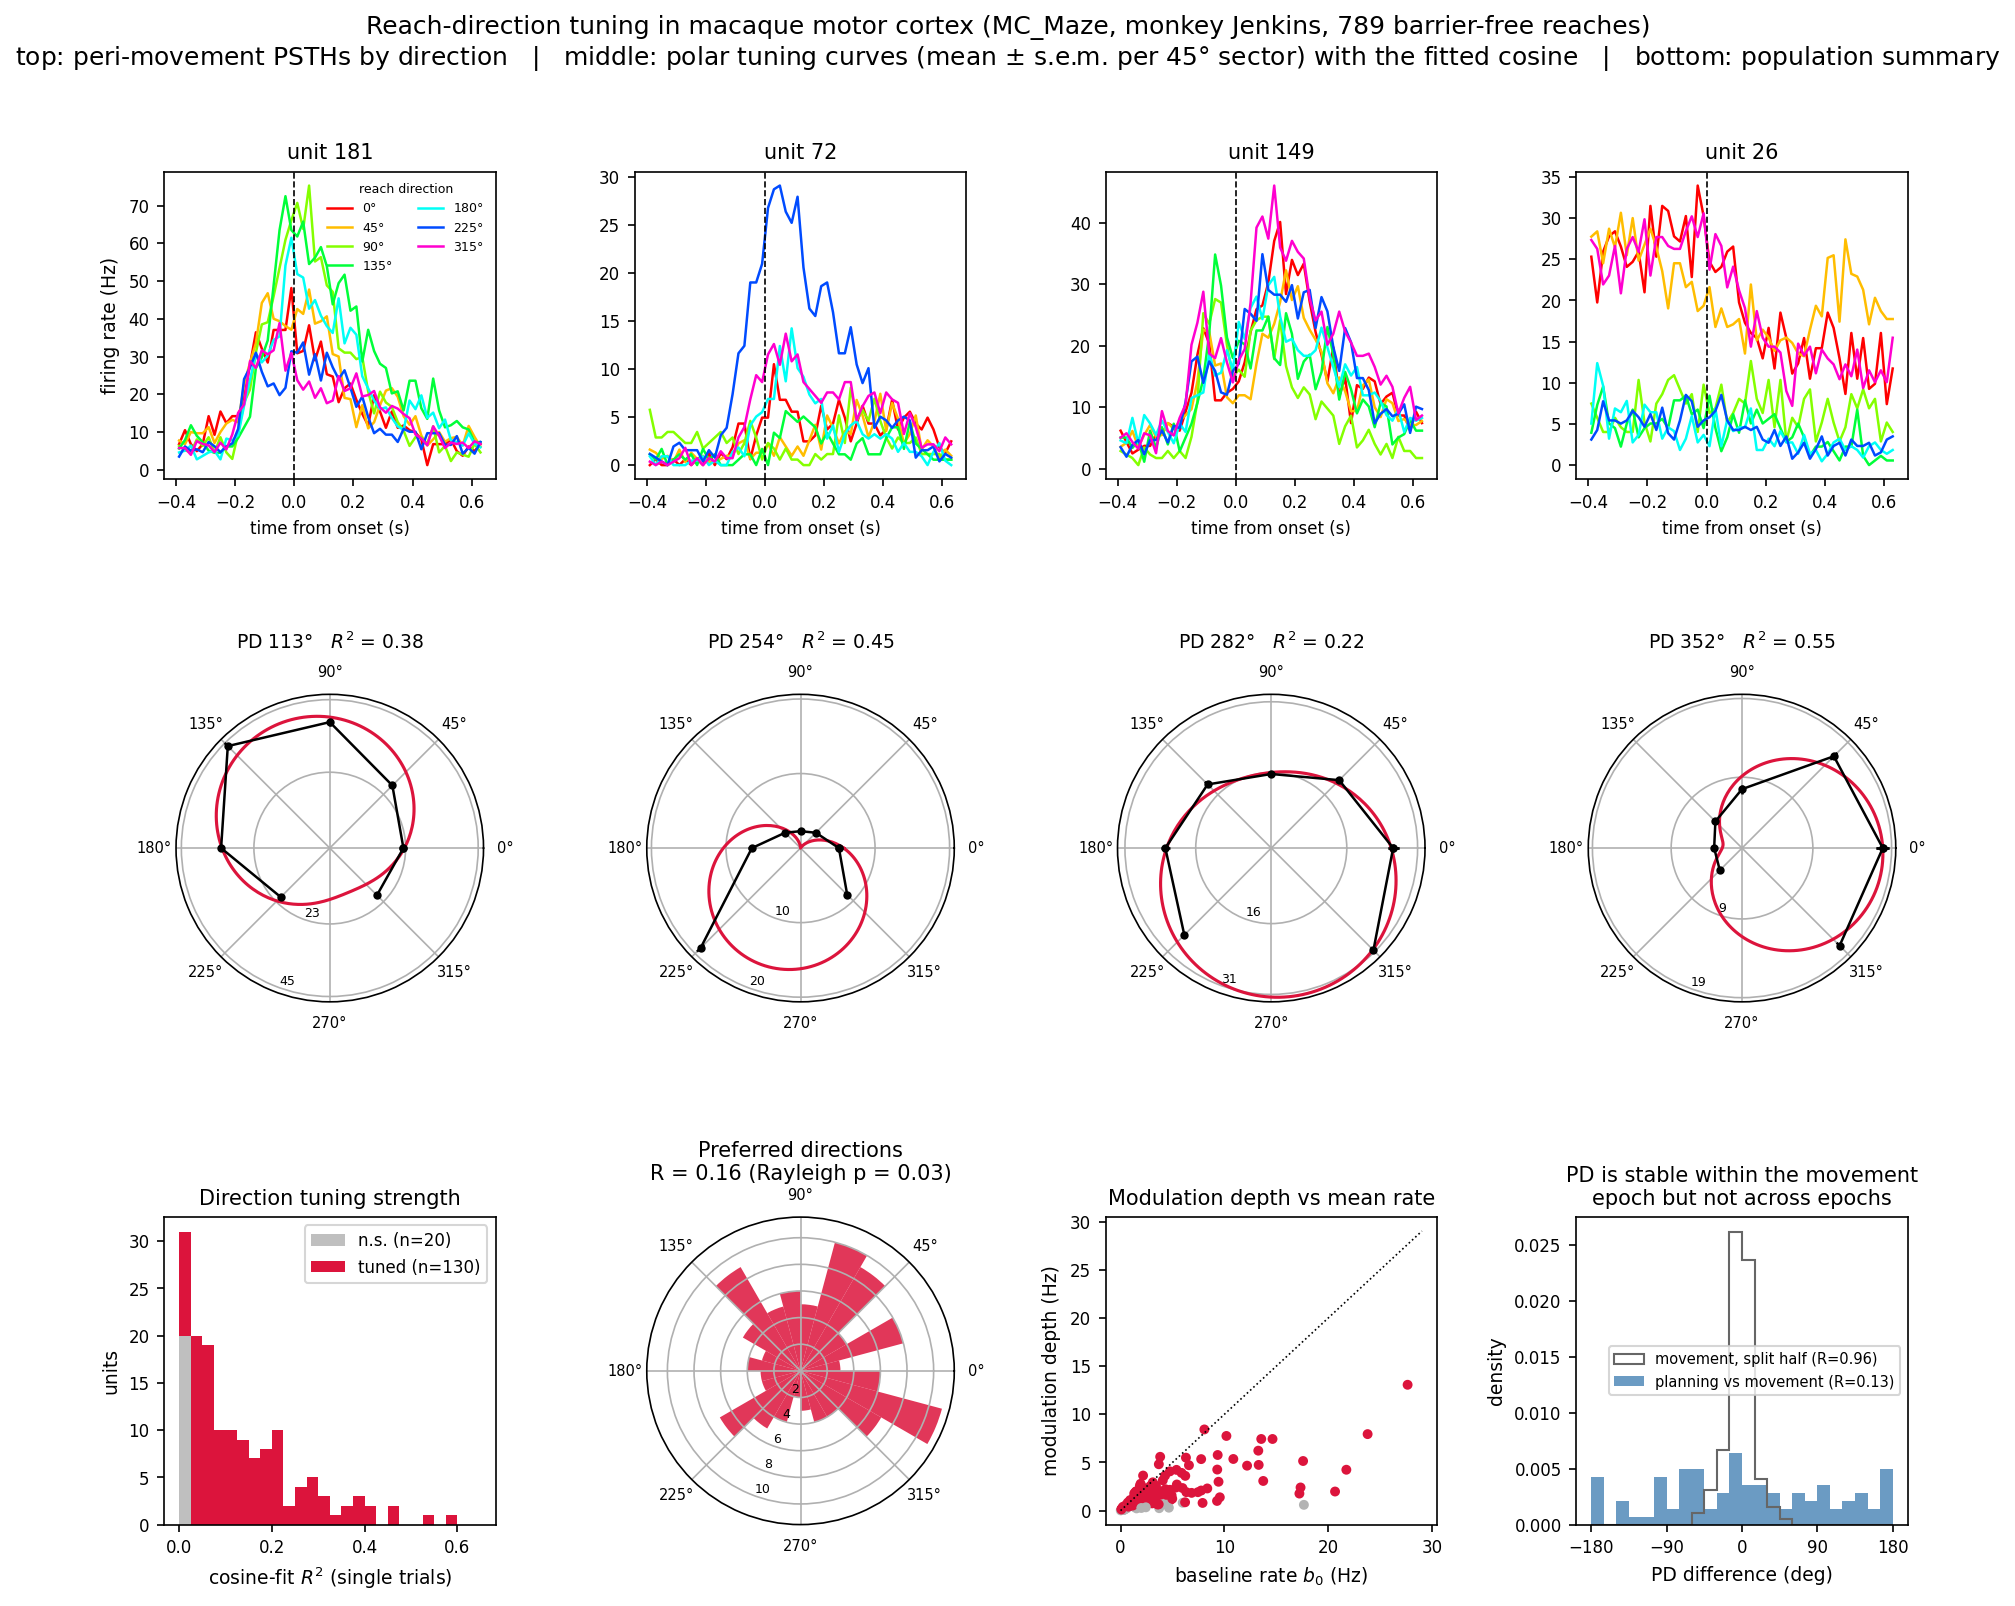

In [7]:
mu, se, centres = an.tuning_curve_by_sector(rates_mov, theta, 8)
examples = np.argsort(-fit_mov["md"] * sig_mov)[:4]

fig = plt.figure(figsize=(15, 11))
gs = fig.add_gridspec(3, 4, hspace=0.70, wspace=0.42, top=0.88, bottom=0.06)
bins = np.arange(-0.4, 0.65, 0.02)
dbin = an.direction_bins(theta, 8)
cmap = plt.get_cmap("hsv")
for c, u in enumerate(examples):
    ax = fig.add_subplot(gs[0, c])
    st = spikes[uid[u]].index.values
    for k in range(8):
        tt = on[dbin == k]
        if len(tt) < 5:                     # no straight-down reaches exist
            continue
        h, _ = np.histogram((st[None, :] - tt[:, None]).ravel(), bins)
        ax.plot(bins[:-1] + 0.01, h / len(tt) / 0.02, color=cmap(k / 8), lw=1.2,
                label=f"{k*45}$\\degree$")
    ax.axvline(0, color="k", ls="--", lw=0.8)
    ax.set_title(f"unit {uid[u]}", fontsize=10)
    ax.set_xlabel("time from onset (s)", fontsize=8)
    if c == 0:
        ax.set_ylabel("firing rate (Hz)", fontsize=9)
        ax.legend(fontsize=6, ncol=2, frameon=False, title="reach direction",
                  title_fontsize=6)

for c, u in enumerate(examples):
    ax = fig.add_subplot(gs[1, c], projection="polar")
    ang = np.append(centres, centres[0])
    m = np.append(mu[:, u], mu[0, u])
    s_ = np.append(se[:, u], se[0, u])
    ax.errorbar(ang, m, yerr=s_, fmt="o-", ms=3, lw=1.2, color="k")
    fine = np.linspace(0, 2 * np.pi, 200)
    ax.plot(fine, np.clip(fit_mov["b0"][u] +
                          fit_mov["md"][u] * np.cos(fine - fit_mov["pd"][u]), 0, None),
            color="crimson", lw=1.5)
    ax.set_title(f"PD {np.degrees(fit_mov['pd'][u]) % 360:.0f}$\\degree$   "
                 f"$R^2$ = {fit_mov['r2'][u]:.2f}", fontsize=9, pad=22)
    rmax = np.nanmax(m + s_)
    ax.set_yticks([round(rmax / 2), round(rmax)])
    ax.tick_params(axis="x", labelsize=7, pad=0)
    ax.tick_params(axis="y", labelsize=6)
    ax.set_rlabel_position(250)

ax = fig.add_subplot(gs[2, 0])
ax.hist([fit_mov["r2"][~sig_mov], fit_mov["r2"][sig_mov]],
        bins=np.linspace(0, 0.65, 27), stacked=True, color=["0.75", "crimson"],
        label=[f"n.s. (n={(~sig_mov).sum()})", f"tuned (n={sig_mov.sum()})"])
ax.set(xlabel="cosine-fit $R^2$ (single trials)", ylabel="units",
       title="Direction tuning strength")
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[2, 1], projection="polar")
ax.hist(np.mod(fit_mov["pd"][sig_mov], 2 * np.pi),
        bins=np.linspace(0, 2 * np.pi, 25), color="crimson", alpha=0.85)
ax.set_title(f"Preferred directions\nR = {R:.2f} (Rayleigh p = {rayleigh_p:.2f})",
             fontsize=10, pad=18)
ax.tick_params(axis="x", labelsize=7, pad=0)
ax.tick_params(axis="y", labelsize=6)
ax.set_rlabel_position(250)

ax = fig.add_subplot(gs[2, 2])
ax.scatter(fit_mov["b0"], fit_mov["md"], s=14, c=np.where(sig_mov, "crimson", "0.7"))
lim = [0, max(fit_mov["b0"].max(), fit_mov["md"].max()) * 1.05]
ax.plot(lim, lim, "k:", lw=0.8)
ax.set(xlabel="baseline rate $b_0$ (Hz)", ylabel="modulation depth (Hz)",
       title="Modulation depth vs mean rate")

ax = fig.add_subplot(gs[2, 3])
eb = np.linspace(-180, 180, 25)
ax.hist(np.degrees(dpd_split), bins=eb, color="0.4", histtype="step", lw=1.8,
        density=True, label=f"movement, split half (R={Rs:.2f})")
ax.hist(np.degrees(dpd), bins=eb, color="steelblue", alpha=0.8, density=True,
        label=f"planning vs movement (R={Rd:.2f})")
ax.set(xlabel="PD difference (deg)", ylabel="density",
       title="PD is stable within the movement\nepoch but not across epochs")
ax.set_xticks([-180, -90, 0, 90, 180])
ax.legend(fontsize=7)

fig.suptitle("Reach-direction tuning in macaque motor cortex "
             f"(MC_Maze, monkey Jenkins, {len(idx)} barrier-free reaches)\n"
             "top: peri-movement PSTHs by direction   |   "
             "middle: polar tuning curves (mean $\\pm$ s.e.m. per 45$\\degree$ sector) "
             "with the fitted cosine   |   bottom: population summary",
             fontsize=12, y=0.975)
save_show(fig, "fig02_direction_tuning.png", bbox_inches="tight")

**What figure 2 shows.** 130 of 150 units are significantly direction tuned
during movement, and the fitted cosine captures the sector means well.
Preferred directions cover the whole circle with only a slight bias
(R = 0.16), which is what a distributed population code looks like.

The last panel is the one worth pausing on.  Split-half estimates of the same
movement-epoch preferred direction agree almost perfectly (R = 0.96, 98%
within 45 degrees), so the method resolves a preferred direction to a few
degrees.  Against that baseline, the delay-period preferred direction is
essentially unrelated to the movement preferred direction (R = 0.13, only 31%
within 45 degrees).  Both epochs are directionally tuned, but they are not
tuned the same way, which is consistent with reports that preparatory and
movement activity in motor cortex occupy different response patterns rather
than a single fixed directional code.

## 3. Velocity tuning

Direction tuning measured trial by trial throws away the time course.  The
next question is whether the moment-to-moment firing rate tracks the
moment-to-moment velocity vector, and with what temporal offset.

All 2295 successful trials are used now, including the curved maze reaches,
because those sweep out a much wider range of velocities.  Spikes are binned
at 20 ms and smoothed with a 30 ms Gaussian.  The maze task repeats 108
distinct conditions about 20 times each, so the analysis is run on
condition-averaged rates: a single 20 ms bin of a 5 Hz neuron is almost pure
Poisson noise, and averaging over repeats of the same condition removes most
of it while leaving the tuning intact.

The lag sweep holds the spike window fixed and resamples the velocity at
increasing offsets.  A peak at a positive offset means the spikes came first.

In [8]:
WIN = (0.0, 0.5)
SD = 0.03
spk = spikes[list(uid)]
idx_all = np.flatnonzero(np.isfinite(tr["move_onset_time"]) & tr["success"].astype(bool))
ntr = len(idx_all)
ep = an.movement_epochs(sess, idx_all, WIN)
counts = spk.count(an.BIN, ep=ep)
rate = an.smooth_rate(counts, sd=SD)
labels = an.condition_labels(sess, idx_all)
print(f"{ntr} trials, {counts.shape[0]} bins of {an.BIN*1000:.0f} ms, "
      f"{counts.shape[1]} units, {len(np.unique(labels))} maze conditions")

lags = np.round(np.arange(-0.30, 0.305, 0.02), 3)
r2_lag = np.empty((len(lags), rate.shape[1]))
dec_lag = np.empty(len(lags))
for i, lg in enumerate(tqdm(lags, desc="lag sweep")):
    mask, v_ = an.sample_velocity(vel, counts, lg)
    assert mask.all()
    Rc, conds = an.condition_average(rate, labels, ntr)
    Vc, _ = an.condition_average(v_, labels, ntr)
    r2_lag[i], _ = an.velocity_regression_r2(Rc, Vc)
    X = np.column_stack([np.ones(len(Rc)), Rc])
    b, *_ = np.linalg.lstsq(X, Vc, rcond=None)
    with np.errstate(all="ignore"):
        pr = X @ b
    dec_lag[i] = np.mean(1 - ((Vc - pr) ** 2).sum(0) / ((Vc - Vc.mean(0)) ** 2).sum(0))

pop_lag = lags[np.argmax(np.nanmedian(r2_lag, axis=1))]
best_lag = lags[np.argmax(r2_lag, axis=0)]
strong = r2_lag.max(0) > 0.15
print(f"single-unit encoding peaks at a lead of {pop_lag*1000:.0f} ms "
      f"(median R2 {np.nanmedian(r2_lag, axis=1).max():.3f}, max unit {r2_lag.max():.3f})")
print(f"population decoding peaks at {lags[np.argmax(dec_lag)]*1000:.0f} ms, "
      f"R2 = {dec_lag.max():.3f}")

2295 trials, 57375 bins of 20 ms, 150 units, 108 maze conditions


lag sweep:   0%|          | 0/31 [00:00<?, ?it/s]

/Users/bdichter/dev/agent-foundational-studies/runs-2026-07-21-exploratory/opus-5/reach-03/analysis.py:233: RuntimeWarning: divide by zero encountered in matmul
  resid = rate - X @ beta
/Users/bdichter/dev/agent-foundational-studies/runs-2026-07-21-exploratory/opus-5/reach-03/analysis.py:233: RuntimeWarning: overflow encountered in matmul
  resid = rate - X @ beta
/Users/bdichter/dev/agent-foundational-studies/runs-2026-07-21-exploratory/opus-5/reach-03/analysis.py:233: RuntimeWarning: invalid value encountered in matmul
  resid = rate - X @ beta


single-unit encoding peaks at a lead of 60 ms (median R2 0.068, max unit 0.512)
population decoding peaks at 80 ms, R2 = 0.942


In [9]:
mask, V = an.sample_velocity(vel, counts, pop_lag)
Rc, conds = an.condition_average(rate, labels, ntr)
Vc, _ = an.condition_average(V, labels, ntr)
r2_vel, beta_vel = an.velocity_regression_r2(Rc, Vc)
pd_vel = np.arctan2(beta_vel[2], beta_vel[1])

sc = np.linalg.norm(Vc, axis=1)
th = np.arctan2(Vc[:, 1], Vc[:, 0])
mov = sc > 50.0
fold = np.repeat(np.arange(len(conds)) % 5, Rc.shape[0] // len(conds))[mov]
Xdir = np.column_stack([np.ones(mov.sum()), np.cos(th[mov]), np.sin(th[mov])])
Xvel = np.column_stack([np.ones(mov.sum()), Vc[mov]])
Xful = np.column_stack([Xdir, Vc[mov]])


def cv_r2(X, y, fold):
    """R^2 with whole maze conditions held out, per column of y."""
    pred = np.empty_like(y)
    for f in np.unique(fold):
        te = fold == f
        b, *_ = np.linalg.lstsq(X[~te], y[~te], rcond=None)
        with np.errstate(all="ignore"):
            pred[te] = X[te] @ b
    return 1 - ((y - pred) ** 2).sum(0) / ((y - y.mean(0)) ** 2).sum(0)


cv_dir, cv_vel, cv_ful = (cv_r2(X, Rc[mov], fold) for X in (Xdir, Xvel, Xful))
print(f"cross-validated R2: direction only {np.median(cv_dir):.3f}, "
      f"velocity vector {np.median(cv_vel):.3f}, both {np.median(cv_ful):.3f}")
print(f"adding the speed-scaled term helps {(cv_ful > cv_dir).sum()}/{len(cv_ful)} units")

centres_s, md_speed, _ = an.speed_gain(rate, V, n_speed=4, pd=pd_vel)
print("speed quartile centres (mm/s):", centres_s.round(0))
print("median modulation along PD (Hz):", np.nanmedian(md_speed, axis=1).round(2))

cross-validated R2: direction only 0.089, velocity vector 0.074, both 0.110
adding the speed-scaled term helps 123/150 units


speed quartile centres (mm/s): [ 14. 144. 476. 736.]
median modulation along PD (Hz): [-0.03  0.32  1.02  1.34]


### Figure 3: velocity tuning

/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/process/tuning_curves.py:633: FutureWarning: compute_2d_tuning_curves_continuous is deprecated and will be removed in a future version;use compute_tuning_curves instead.
  return func(**kwargs)


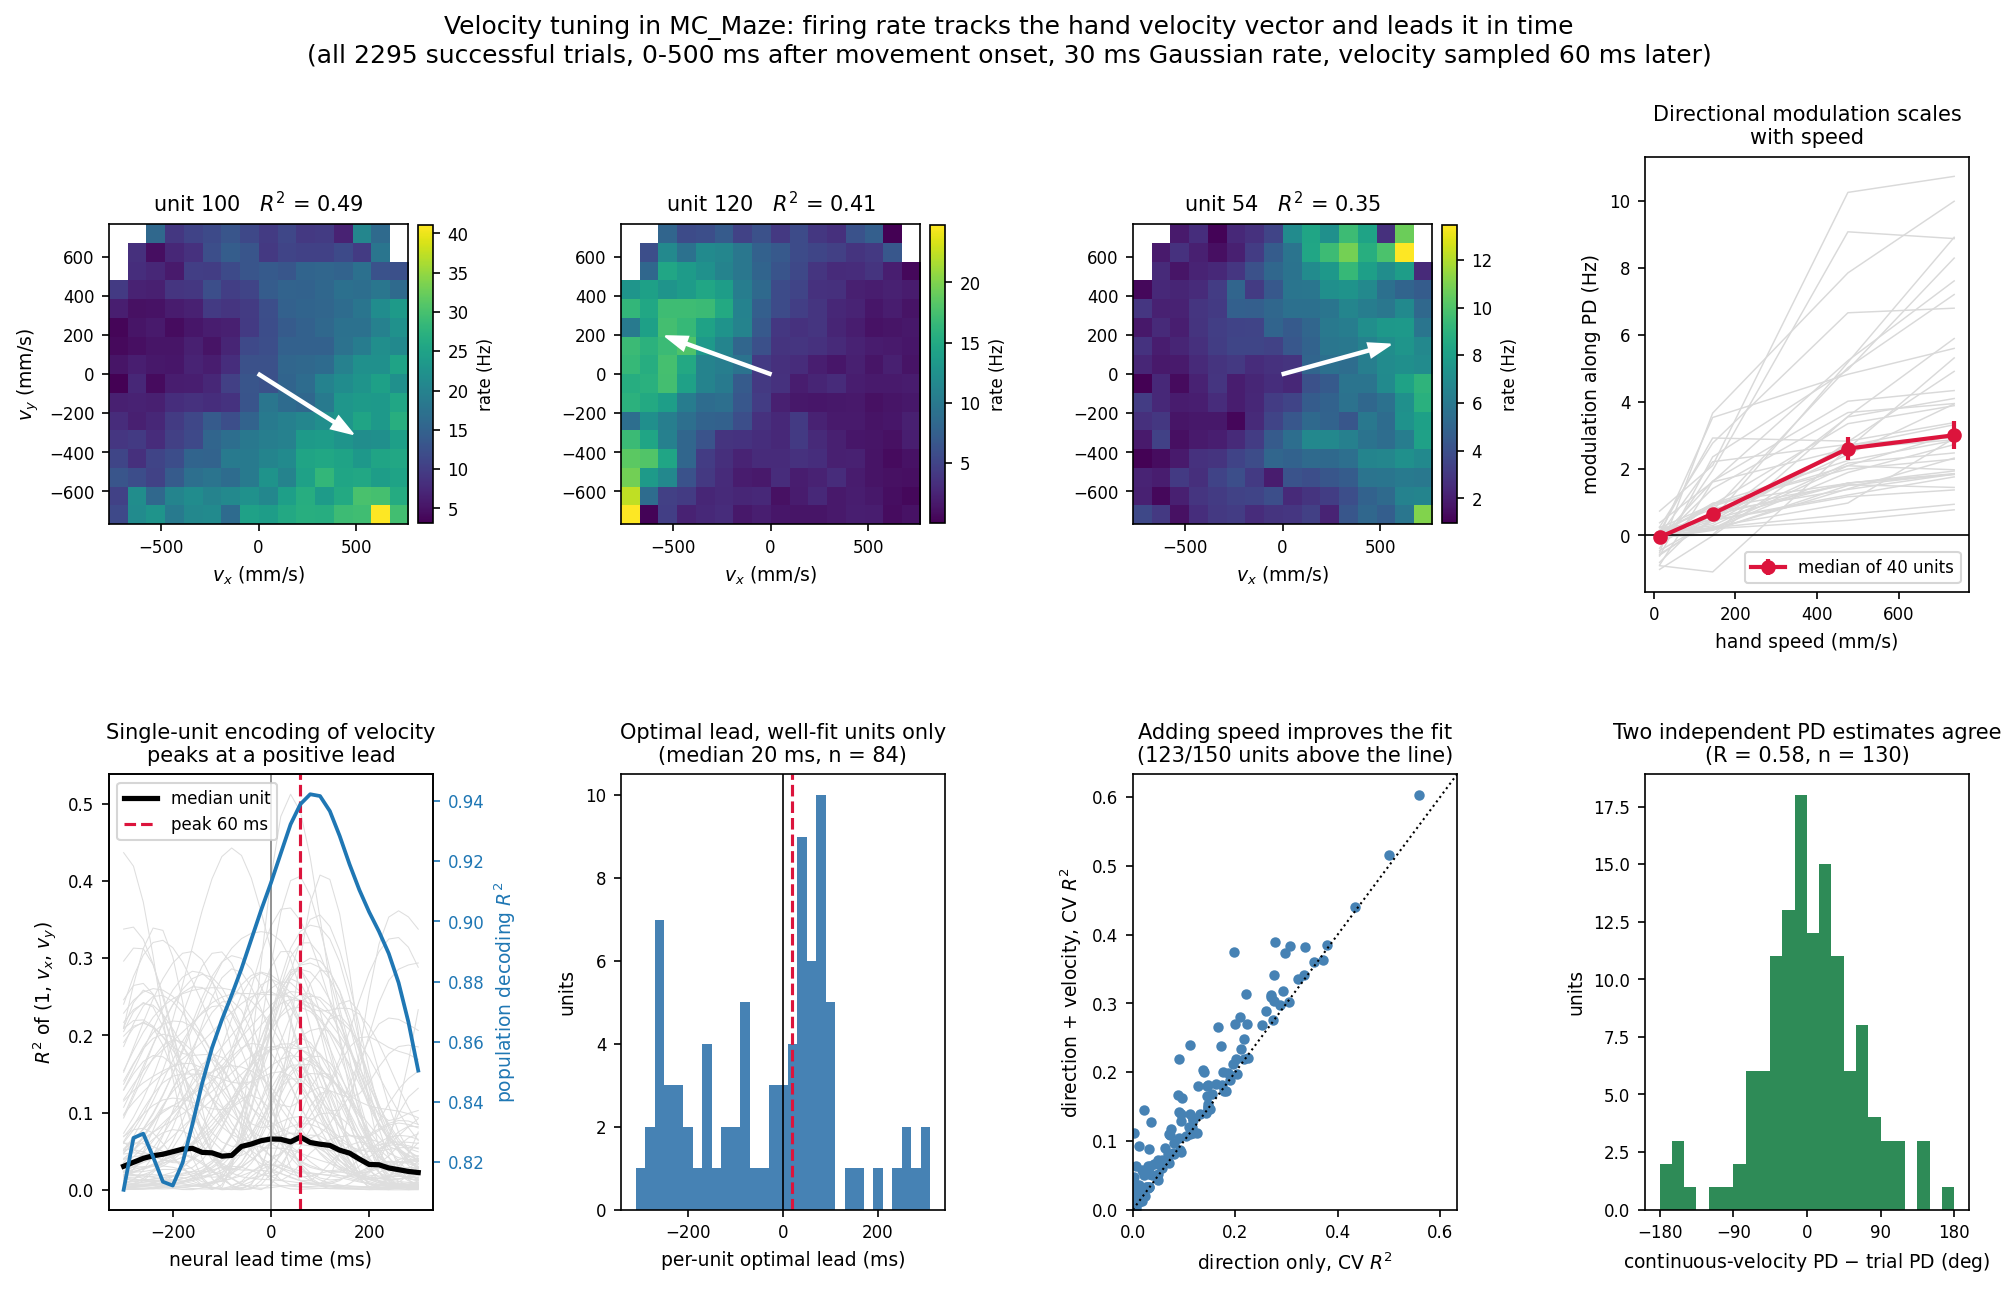

In [10]:
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 4, hspace=0.42, wspace=0.58, top=0.86, bottom=0.08)

vfr = nap.TsdFrame(t=counts.index.values, d=V, columns=["vx", "vy"])
examples_v = np.argsort(-r2_vel)[:3]
lim = np.percentile(np.abs(V), 99)
for c, u in enumerate(examples_v):
    ax = fig.add_subplot(gs[0, c])
    tc, edges = nap.compute_2d_tuning_curves_continuous(
        nap.TsdFrame(t=vfr.index.values, d=rate[:, [u]]), vfr, nb_bins=16,
        minmax=(-lim, lim, -lim, lim))
    im = ax.imshow(tc[0].T, origin="lower", cmap="viridis", aspect="equal",
                   extent=[edges[0][0], edges[0][-1], edges[1][0], edges[1][-1]])
    ax.arrow(0, 0, 0.7 * lim * np.cos(pd_vel[u]), 0.7 * lim * np.sin(pd_vel[u]),
             color="w", width=lim * 0.015, head_width=lim * 0.09,
             length_includes_head=True)
    ax.set(xlabel="$v_x$ (mm/s)", ylabel="$v_y$ (mm/s)" if c == 0 else "",
           title=f"unit {uid[u]}   $R^2$ = {r2_vel[u]:.2f}")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03).set_label("rate (Hz)", size=8)

ax = fig.add_subplot(gs[0, 3])
sel = np.argsort(-r2_vel)[:40]
for u in sel:
    ax.plot(centres_s, md_speed[:, u], color="0.85", lw=0.7)
ax.errorbar(centres_s, np.nanmedian(md_speed[:, sel], axis=1),
            yerr=np.nanstd(md_speed[:, sel], axis=1) / np.sqrt(len(sel)),
            color="crimson", lw=2, marker="o", label="median of 40 units")
ax.axhline(0, color="k", lw=0.8)
ax.legend(fontsize=8)
ax.set(xlabel="hand speed (mm/s)", ylabel="modulation along PD (Hz)",
       title="Directional modulation scales\nwith speed")

ax = fig.add_subplot(gs[1, 0])
ax.plot(lags * 1000, r2_lag[:, strong], color="0.87", lw=0.5)
ax.plot(lags * 1000, np.nanmedian(r2_lag, axis=1), "k", lw=2.5, label="median unit")
ax.axvline(pop_lag * 1000, color="crimson", ls="--", label=f"peak {pop_lag*1000:.0f} ms")
ax.axvline(0, color="0.5", lw=0.8)
ax.set(xlabel="neural lead time (ms)", ylabel="$R^2$ of (1, $v_x$, $v_y$)",
       title="Single-unit encoding of velocity\npeaks at a positive lead")
ax.legend(fontsize=8)
ax2 = ax.twinx()
ax2.plot(lags * 1000, dec_lag, color="tab:blue", lw=1.8)
ax2.set_ylabel("population decoding $R^2$", color="tab:blue", fontsize=9)
ax2.tick_params(axis="y", colors="tab:blue", labelsize=8)

ax = fig.add_subplot(gs[1, 1])
ax.hist(best_lag[strong] * 1000, bins=np.arange(-310, 311, 20), color="steelblue")
ax.axvline(0, color="k", lw=0.8)
ax.axvline(np.median(best_lag[strong]) * 1000, color="crimson", ls="--")
ax.set(xlabel="per-unit optimal lead (ms)", ylabel="units",
       title=f"Optimal lead, well-fit units only\n"
             f"(median {np.median(best_lag[strong])*1000:.0f} ms, n = {strong.sum()})")

ax = fig.add_subplot(gs[1, 2])
ax.scatter(cv_dir, cv_ful, s=16, c="steelblue")
m = max(np.nanmax(cv_dir), np.nanmax(cv_ful)) * 1.05
ax.plot([0, m], [0, m], "k:", lw=1)
ax.set(xlim=(0, m), ylim=(0, m), xlabel="direction only, CV $R^2$",
       ylabel="direction + velocity, CV $R^2$",
       title=f"Adding speed improves the fit\n"
             f"({(cv_ful > cv_dir).sum()}/{len(cv_ful)} units above the line)")

ax = fig.add_subplot(gs[1, 3])
dd = np.degrees(np.angle(np.exp(1j * (pd_vel - fit_mov["pd"]))))
ax.hist(dd[sig_mov], bins=np.linspace(-180, 180, 25), color="seagreen")
Rc_agree = np.abs(np.exp(1j * np.radians(dd[sig_mov])).mean())
ax.set(xlabel="continuous-velocity PD $-$ trial PD (deg)", ylabel="units",
       title=f"Two independent PD estimates agree\n"
             f"(R = {Rc_agree:.2f}, n = {sig_mov.sum()})")
ax.set_xticks([-180, -90, 0, 90, 180])

fig.suptitle("Velocity tuning in MC_Maze: firing rate tracks the hand velocity "
             "vector and leads it in time\n"
             f"(all {ntr} successful trials, 0-500 ms after movement onset, "
             f"{SD*1000:.0f} ms Gaussian rate, velocity sampled "
             f"{pop_lag*1000:.0f} ms later)", fontsize=12, y=0.965)
save_show(fig, "fig03_velocity_tuning.png", bbox_inches="tight")

**What figure 3 shows.** The 2D velocity tuning maps are smooth gradients
across the velocity plane rather than isolated blobs, and the arrow (the
preferred direction from the linear fit) points up the gradient.  Directional
modulation grows from -0.03 Hz in the slowest quartile of hand speeds
(14 mm/s) to 1.34 Hz in the fastest (736 mm/s) across all 150 units, and to
about 3 Hz among the 40 best-fit units, which is the signature of
velocity-vector rather than direction-only coding.  Preferred directions estimated two independent ways,
from trial-averaged rates over straight reaches and from continuous velocity
over all reaches, agree (R = 0.58).

Single-unit R^2 is modest: the median unit reaches only 0.07 and the best
0.51.  That is the honest number for a static velocity model of motor cortex,
which is known not to capture the large condition-independent and preparatory
components of the response.  Read from the other direction the same data look
much stronger, because velocity is a population code: a linear readout of all
150 units recovers the condition-averaged velocity with R^2 = 0.94.

## 4. Poisson GLMs and single-trial decoding

The regressions above are least-squares fits to a smoothed rate.  NeMoS fits
the proper observation model, a Poisson GLM on raw 20 ms spike counts, and
lets three nested feature sets be compared on held-out trials:

* `direction`  cos and sin of the movement direction (2 features)
* `velocity`   a linear function of (vx, vy), direction scaled by speed (2 features)
* `2D spline`  a 6 x 6 B-spline surface over the velocity plane (36 features)

Folds are whole trials, never individual bins, because neighbouring bins are
strongly correlated.

In [11]:
LEAD = 0.08
SPEED_MIN = 50.0
mask, V4 = an.sample_velocity(vel, counts, LEAD)
assert mask.all()
Y = np.asarray(counts.values, float)
per = Y.shape[0] // ntr
speed4 = np.linalg.norm(V4, axis=1)
theta4 = np.arctan2(V4[:, 1], V4[:, 0])
bin_fold = np.repeat(np.random.default_rng(0).permutation(ntr) % 5, per)
mov4 = speed4 > SPEED_MIN

vscale = np.percentile(speed4, 99)
Vn = V4 / vscale
basis2d = (nmo.basis.BSplineEval(n_basis_funcs=6, label="vx") *
           nmo.basis.BSplineEval(n_basis_funcs=6, label="vy"))
X_full = np.asarray(basis2d.compute_features(Vn[:, 0], Vn[:, 1]))
FEATURES = {"direction": np.column_stack([np.cos(theta4), np.sin(theta4)]),
            "velocity": Vn,
            "2D spline": X_full}


def poisson_pseudo_r2(y, mu, y_train_mean):
    """McFadden pseudo-R^2 against a constant-rate null, per unit."""
    eps = 1e-9
    ll = y * np.log(mu + eps) - mu
    ll0 = y * np.log(y_train_mean + eps) - y_train_mean
    lls = y * np.log(y + eps) - y
    return 1 - (lls - ll).sum(0) / (lls - ll0).sum(0)


pseudo = {}
for name, X in FEATURES.items():
    pr2 = np.zeros((5, Y.shape[1]))
    for f in tqdm(range(5), desc=f"GLM {name}"):
        te = (bin_fold == f) & mov4
        trn = (bin_fold != f) & mov4
        model = nmo.glm.PopulationGLM(observation_model="Poisson",
                                      regularizer="Ridge",
                                      regularizer_strength=1e-3,
                                      solver_name="LBFGS").fit(X[trn], Y[trn])
        pr2[f] = poisson_pseudo_r2(Y[te], np.asarray(model.predict(X[te])),
                                   Y[trn].mean(0))
    pseudo[name] = pr2.mean(0)
    print(f"{name:10s} cross-validated pseudo-R2: median {np.median(pseudo[name]):.4f}, "
          f"90th pct {np.percentile(pseudo[name], 90):.4f}")

print(f"speed term helps {(pseudo['velocity'] > pseudo['direction']).sum()}/"
      f"{Y.shape[1]} units, the spline surface helps a further "
      f"{(pseudo['2D spline'] > pseudo['velocity']).sum()}/{Y.shape[1]}")

GLM direction:   0%|          | 0/5 [00:00<?, ?it/s]

direction  cross-validated pseudo-R2: median 0.0117, 90th pct 0.0657


GLM velocity:   0%|          | 0/5 [00:00<?, ?it/s]

velocity   cross-validated pseudo-R2: median 0.0125, 90th pct 0.0643


GLM 2D spline:   0%|          | 0/5 [00:00<?, ?it/s]

2D spline  cross-validated pseudo-R2: median 0.0177, 90th pct 0.0560
speed term helps 92/150 units, the spline surface helps a further 98/150


In [12]:
rate4 = an.smooth_rate(counts, sd=0.03)
dec_pred = np.empty_like(V4)
for f in range(5):
    te = bin_fold == f
    dec_pred[te] = Ridge(alpha=1.0).fit(rate4[~te], V4[~te]).predict(rate4[te])
dec_r2 = 1 - ((V4 - dec_pred) ** 2).sum(0) / ((V4 - V4.mean(0)) ** 2).sum(0)
print(f"single-trial decoding on held-out trials: R2 = {dec_r2[0]:.3f} ($v_x$), "
      f"{dec_r2[1]:.3f} ($v_y$)")

sizes = [1, 2, 5, 10, 20, 40, 80, len(uid)]
curve = np.zeros((len(sizes), 5))
for i, n in enumerate(tqdm(sizes, desc="decoder size")):
    for rep in range(5):
        sub = np.random.default_rng(rep).choice(len(uid), n, replace=False)
        pr = np.empty_like(V4)
        for f in range(5):
            te = bin_fold == f
            pr[te] = Ridge(alpha=1.0).fit(rate4[~te][:, sub], V4[~te]).predict(rate4[te][:, sub])
        curve[i, rep] = np.mean(1 - ((V4 - pr) ** 2).sum(0) /
                                ((V4 - V4.mean(0)) ** 2).sum(0))
print("decoding R2 vs population size:", dict(zip(sizes, curve.mean(1).round(3))))

/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: overflow encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_.T + self.intercept_
/Users

/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: overflow encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_.T + self.intercept_
/Users

single-trial decoding on held-out trials: R2 = 0.624 ($v_x$), 0.517 ($v_y$)


decoder size:   0%|          | 0/8 [00:00<?, ?it/s]

/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWar

...

/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: overflow encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_.T + self.intercept_
/Users

/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: overflow encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_.T + self.intercept_
/Users

/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: overflow encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_.T + self.intercept_


decoding R2 vs population size: {1: np.float64(0.004), 2: np.float64(0.003), 5: np.float64(0.034), 10: np.float64(0.079), 20: np.float64(0.163), 40: np.float64(0.286), 80: np.float64(0.43), 150: np.float64(0.57)}


/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: overflow encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_.T + self.intercept_
/Users

### Figure 4: GLM encoding and population decoding

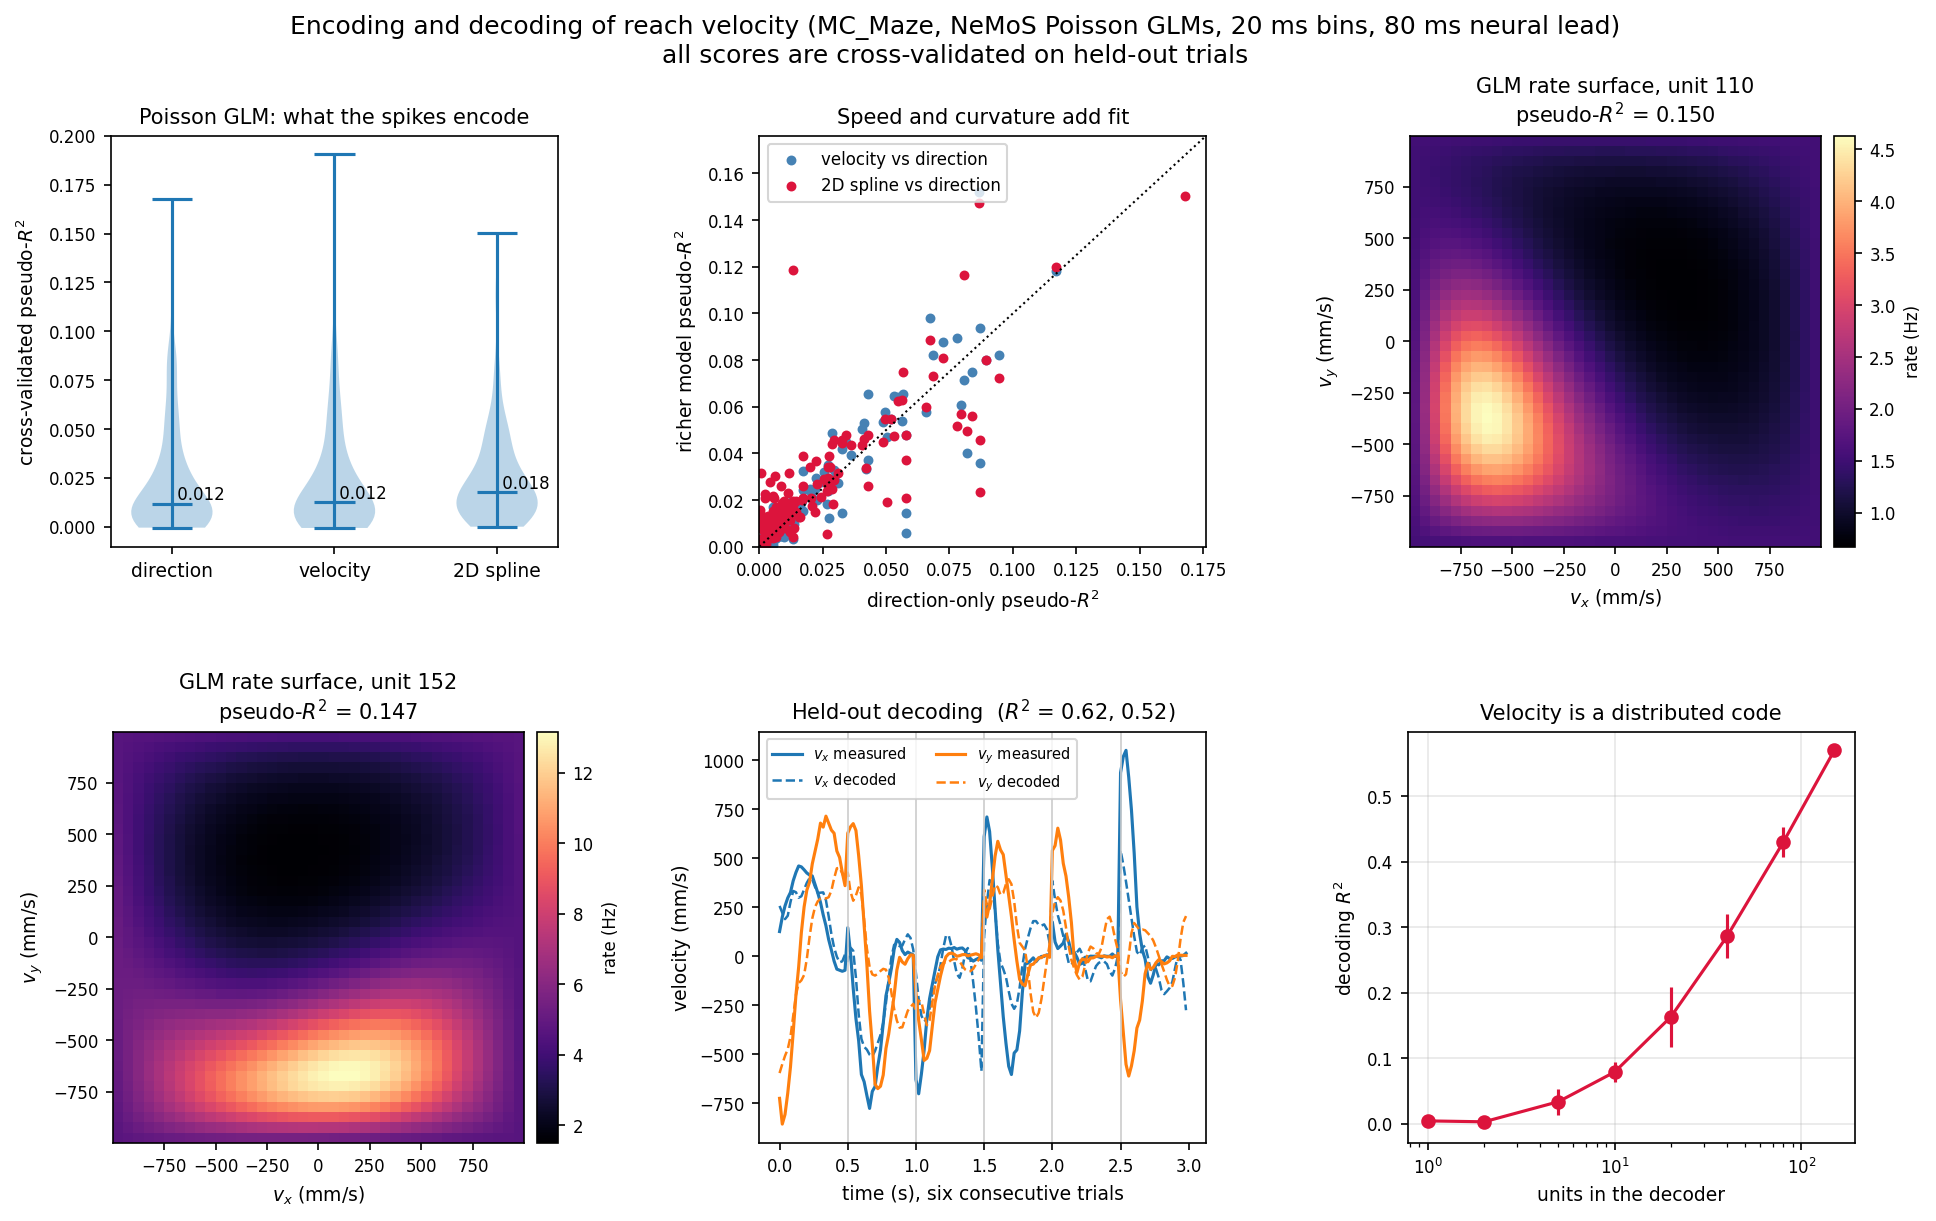

In [13]:
fig = plt.figure(figsize=(15, 8.5))
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.45, top=0.87, bottom=0.08)

ax = fig.add_subplot(gs[0, 0])
data = [pseudo[k] for k in FEATURES]
ax.violinplot(data, showmedians=True)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(list(FEATURES), fontsize=9)
ax.set(ylabel="cross-validated pseudo-$R^2$",
       title="Poisson GLM: what the spikes encode")
for i, d in enumerate(data):
    ax.text(i + 1, np.median(d), f" {np.median(d):.3f}", fontsize=8, va="bottom")

ax = fig.add_subplot(gs[0, 1])
ax.scatter(pseudo["direction"], pseudo["velocity"], s=14, c="steelblue",
           label="velocity vs direction")
ax.scatter(pseudo["direction"], pseudo["2D spline"], s=14, c="crimson",
           label="2D spline vs direction")
m = max(np.max(pseudo["2D spline"]), np.max(pseudo["direction"])) * 1.05
ax.plot([0, m], [0, m], "k:", lw=1)
ax.set(xlim=(0, m), ylim=(0, m), xlabel="direction-only pseudo-$R^2$",
       ylabel="richer model pseudo-$R^2$", title="Speed and curvature add fit")
ax.legend(fontsize=8, loc="upper left")

model = nmo.glm.PopulationGLM(observation_model="Poisson", regularizer="Ridge",
                              regularizer_strength=1e-3,
                              solver_name="LBFGS").fit(X_full[mov4], Y[mov4])
grid = np.linspace(-1, 1, 40)
gx, gy = np.meshgrid(grid, grid)
mu_grid = np.asarray(model.predict(
    np.asarray(basis2d.compute_features(gx.ravel(), gy.ravel())))) / an.BIN
best = np.argsort(-pseudo["2D spline"])[:2]
for c, u in enumerate(best):
    ax = fig.add_subplot(gs[0, 2] if c == 0 else gs[1, 0])
    im = ax.pcolormesh(gx * vscale, gy * vscale, mu_grid[:, u].reshape(gx.shape),
                       cmap="magma", shading="auto")
    ax.set(xlabel="$v_x$ (mm/s)", ylabel="$v_y$ (mm/s)", aspect="equal",
           title=f"GLM rate surface, unit {uid[u]}\n"
                 f"pseudo-$R^2$ = {pseudo['2D spline'][u]:.3f}")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03).set_label("rate (Hz)", size=8)

ax = fig.add_subplot(gs[1, 1])
win_bins = np.arange(per * 6)
t_ms = np.arange(len(win_bins)) * an.BIN
for k, (lab, col) in enumerate([("$v_x$", "tab:blue"), ("$v_y$", "tab:orange")]):
    ax.plot(t_ms, V4[win_bins, k], color=col, lw=1.5, label=f"{lab} measured")
    ax.plot(t_ms, dec_pred[win_bins, k], color=col, lw=1.2, ls="--", label=f"{lab} decoded")
for b in range(1, 6):
    ax.axvline(b * per * an.BIN, color="0.8", lw=0.8)
ax.legend(fontsize=7, ncol=2)
ax.set(xlabel="time (s), six consecutive trials", ylabel="velocity (mm/s)",
       title=f"Held-out decoding  ($R^2$ = {dec_r2[0]:.2f}, {dec_r2[1]:.2f})")

ax = fig.add_subplot(gs[1, 2])
ax.errorbar(sizes, curve.mean(1), yerr=curve.std(1), marker="o", color="crimson")
ax.set_xscale("log")
ax.grid(alpha=0.3)
ax.set(xlabel="units in the decoder", ylabel="decoding $R^2$",
       title="Velocity is a distributed code")

fig.suptitle("Encoding and decoding of reach velocity (MC_Maze, NeMoS Poisson GLMs, "
             f"{an.BIN*1000:.0f} ms bins, {LEAD*1000:.0f} ms neural lead)\n"
             "all scores are cross-validated on held-out trials",
             fontsize=12, y=0.965)
save_show(fig, "fig04_glm_decoding.png", bbox_inches="tight")

**What figure 4 shows.** On raw single-trial spike counts the GLM
pseudo-R^2 values are small in absolute terms (median 0.012 for the
direction model), which is what a Poisson likelihood on 20 ms bins of a few
spikes looks like.  The comparison between models is the informative part:
the spline surface roughly doubles the median fit over the direction model,
so the dependence on velocity is real, graded and mildly nonlinear.  The
fitted rate surfaces are broad gradients centred off the origin, exactly the
shape a speed-scaled cosine predicts.

Single-trial decoding of held-out trials recovers hand velocity with
R^2 = 0.62 and 0.52 for the two components, and the decoding accuracy grows
steadily with the number of units, from ~0 for one unit to 0.57 for all 150.
No individual neuron carries the movement; the population does.

## 5. Does this generalise? Six sessions, three experiments, two areas

The whole velocity pipeline is now run unchanged on all six sessions.  The
same 20 ms bins, the same smoothing, the same lag sweep, the same
cross-validated ridge decoder.  Cross-validation folds are contiguous 30 s
blocks of session time so that neighbouring correlated bins cannot leak
between training and test.

The prediction that makes this a test rather than a demonstration: area 2 of
somatosensory cortex receives proprioceptive afference, so its optimal lead
should be negative where motor cortex is positive.

In [14]:
LAGS = np.round(np.arange(-0.30, 0.301, 0.025), 4)
KEYS = ["maze_full", "maze_large", "maze_medium", "maze_small", "rtt", "area2"]


def session_epochs(key, s):
    tr_ = s["trials"]
    if key == "rtt":
        # self-paced task with no trial events: use the 600 ms segments the
        # benchmark release already carved the recording into, trimmed slightly
        # so that consecutive segments stay separate
        return nap.IntervalSet(tr_["start_time"], tr_["start_time"] + 0.595), None
    ok = np.isfinite(tr_["move_onset_time"]) & tr_["success"].astype(bool)
    if key == "area2":
        ok &= ~tr_["ctr_hold_bump"].astype(bool)      # active reaches only
    ii = np.flatnonzero(ok)
    onset = tr_["move_onset_time"][ii]
    return nap.IntervalSet(onset, onset + 0.5), ii


def profile(key):
    s = dio.load_session(key)
    sp, _, vl, _ = dio.to_pynapple(s)
    kp = an.quality_units(sp, dio.trial_intervals(s), min_rate=0.5)
    sp = sp[list(np.flatnonzero(kp))]
    epk, _ = session_epochs(key, s)
    cnt = sp.count(an.BIN, ep=epk)
    rt = an.smooth_rate(cnt, sd=SD)
    fld = an.time_block_folds(cnt.index.values, n_folds=5, block=30.0)

    enc = np.full((len(LAGS), rt.shape[1]), np.nan)
    dec = np.full(len(LAGS), np.nan)
    dec_folds = np.full((len(LAGS), 5), np.nan)
    for i, lg in enumerate(LAGS):
        mk, Vv = an.sample_velocity(vl, cnt, lg)
        Rt, fd = rt[mk], fld[mk]
        enc[i], _ = an.velocity_regression_r2(Rt, Vv)
        pred = np.empty_like(Vv)
        for f in range(5):
            te = fd == f
            pred[te] = Ridge(alpha=1.0).fit(Rt[~te], Vv[~te]).predict(Rt[te])
            dec_folds[i, f] = np.mean(1 - ((Vv[te] - pred[te]) ** 2).sum(0) /
                                      ((Vv[te] - Vv[te].mean(0)) ** 2).sum(0))
        dec[i] = np.mean(1 - ((Vv - pred) ** 2).sum(0) / ((Vv - Vv.mean(0)) ** 2).sum(0))

    lead = LAGS[np.nanargmax(dec)]
    mk, Vv = an.sample_velocity(vl, cnt, lead)
    _, bt = an.velocity_regression_r2(rt[mk], Vv)
    cen, md, _ = an.speed_gain(rt[mk], Vv, n_speed=4, pd=np.arctan2(bt[2], bt[1]))

    tr_ = s["trials"]
    if key.startswith("maze"):
        si = an.straight_trials(s)
        th_, _ = an.reach_direction(s, si)
        onset = tr_["move_onset_time"][si]
    elif key == "area2":
        si = np.flatnonzero(np.isfinite(tr_["move_onset_time"]) &
                            tr_["success"].astype(bool) &
                            ~tr_["ctr_hold_bump"].astype(bool))
        th_ = np.radians(tr_["cond_dir"][si])
        onset = tr_["move_onset_time"][si]
    else:
        th_ = None
    if th_ is not None:
        rr, _ = an.epoch_rates(sp, onset, onset + 0.35)
        ft = an.fit_cosine_tuning(rr, th_, n_perm=300)
        dirtuned = float((ft["p_perm"] < 0.01).mean())
        dir_r2 = float(np.nanmedian(ft["r2"][ft["p_perm"] < 0.01]))
        ntheta = len(th_)
    else:
        dirtuned, dir_r2, ntheta = np.nan, np.nan, 0

    return dict(key=key, label=str(s["session_label"]), monkey=str(s["monkey"]),
                area=str(s["area"]), n_units=rt.shape[1], n_epochs=len(epk),
                enc=enc, dec=dec, lead=lead, dec_peak=float(np.nanmax(dec)),
                lead_folds=LAGS[np.nanargmax(dec_folds, axis=0)],
                r2_best=enc[np.nanargmax(dec)], centres=cen, md=md,
                dirtuned=dirtuned, dir_r2=dir_r2, ntheta=ntheta)


res = [profile(k) for k in tqdm(KEYS, desc="sessions")]

print(f"{'session':38s} {'units':>5s} {'epochs':>6s} {'lead':>7s} {'decR2':>6s} "
      f"{'medEnc':>7s} {'tuned':>6s} {'dirR2':>6s}")
for r in res:
    tuned = "   n/a" if np.isnan(r["dirtuned"]) else f"{r['dirtuned']*100:5.0f}%"
    print(f"{r['label']:38s} {r['n_units']:5d} {r['n_epochs']:6d} "
          f"{r['lead']*1000:+5.0f}ms {r['dec_peak']:6.3f} "
          f"{np.nanmedian(r['r2_best']):7.3f} {tuned:>6s} {r['dir_r2']:6.3f}")

sessions:   0%|          | 0/6 [00:00<?, ?it/s]

/Users/bdichter/dev/agent-foundational-studies/runs-2026-07-21-exploratory/opus-5/reach-03/analysis.py:233: RuntimeWarning: divide by zero encountered in matmul
  resid = rate - X @ beta
/Users/bdichter/dev/agent-foundational-studies/runs-2026-07-21-exploratory/opus-5/reach-03/analysis.py:233: RuntimeWarning: overflow encountered in matmul
  resid = rate - X @ beta
/Users/bdichter/dev/agent-foundational-studies/runs-2026-07-21-exploratory/opus-5/reach-03/analysis.py:233: RuntimeWarning: invalid value encountered in matmul
  resid = rate - X @ beta


/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: overflow encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_.T + self.intercept_
/Users

/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: overflow encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_.T + self.intercept_
/Users

/Users/bdichter/dev/agent-foundational-studies/runs-2026-07-21-exploratory/opus-5/reach-03/analysis.py:233: RuntimeWarning: divide by zero encountered in matmul
  resid = rate - X @ beta
/Users/bdichter/dev/agent-foundational-studies/runs-2026-07-21-exploratory/opus-5/reach-03/analysis.py:233: RuntimeWarning: overflow encountered in matmul
  resid = rate - X @ beta
/Users/bdichter/dev/agent-foundational-studies/runs-2026-07-21-exploratory/opus-5/reach-03/analysis.py:233: RuntimeWarning: invalid value encountered in matmul
  resid = rate - X @ beta
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

...

/Users/bdichter/dev/agent-foundational-studies/runs-2026-07-21-exploratory/opus-5/reach-03/analysis.py:233: RuntimeWarning: divide by zero encountered in matmul
  resid = rate - X @ beta
/Users/bdichter/dev/agent-foundational-studies/runs-2026-07-21-exploratory/opus-5/reach-03/analysis.py:233: RuntimeWarning: overflow encountered in matmul
  resid = rate - X @ beta
/Users/bdichter/dev/agent-foundational-studies/runs-2026-07-21-exploratory/opus-5/reach-03/analysis.py:233: RuntimeWarning: invalid value encountered in matmul
  resid = rate - X @ beta
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

/Users/bdichter/dev/agent-foundational-studies/runs-2026-07-21-exploratory/opus-5/reach-03/analysis.py:233: RuntimeWarning: divide by zero encountered in matmul
  resid = rate - X @ beta
/Users/bdichter/dev/agent-foundational-studies/runs-2026-07-21-exploratory/opus-5/reach-03/analysis.py:233: RuntimeWarning: overflow encountered in matmul
  resid = rate - X @ beta
/Users/bdichter/dev/agent-foundational-studies/runs-2026-07-21-exploratory/opus-5/reach-03/analysis.py:233: RuntimeWarning: invalid value encountered in matmul
  resid = rate - X @ beta
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: overflow encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_.T + self.intercept_
/Users

/Users/bdichter/dev/agent-foundational-studies/runs-2026-07-21-exploratory/opus-5/reach-03/analysis.py:233: RuntimeWarning: divide by zero encountered in matmul
  resid = rate - X @ beta
/Users/bdichter/dev/agent-foundational-studies/runs-2026-07-21-exploratory/opus-5/reach-03/analysis.py:233: RuntimeWarning: overflow encountered in matmul
  resid = rate - X @ beta
/Users/bdichter/dev/agent-foundational-studies/runs-2026-07-21-exploratory/opus-5/reach-03/analysis.py:233: RuntimeWarning: invalid value encountered in matmul
  resid = rate - X @ beta
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/bdichter/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

session                                units epochs    lead  decR2  medEnc  tuned  dirR2
MC_Maze full (Jenkins 2009-09-25)        150   2295   +75ms  0.572   0.011    86%  0.107
MC_Maze large (Jenkins 2009-10-06)       147    500  +100ms  0.561   0.012    63%  0.206
MC_Maze medium (Jenkins 2009-09-29)      128    250   +75ms  0.457   0.010    38%  0.265
MC_Maze small (Jenkins 2009-09-28)       123    100   -75ms  0.332   0.015    13%  0.421
MC_RTT (Indy 2017-02-02)                 111   1080  +100ms  0.404   0.007    n/a    nan
Area2_Bump (Han 2017-12-07)               56    193   -75ms  0.664   0.047    77%  0.280


### Figure 5: the same tuning across sessions, tasks, monkeys and areas

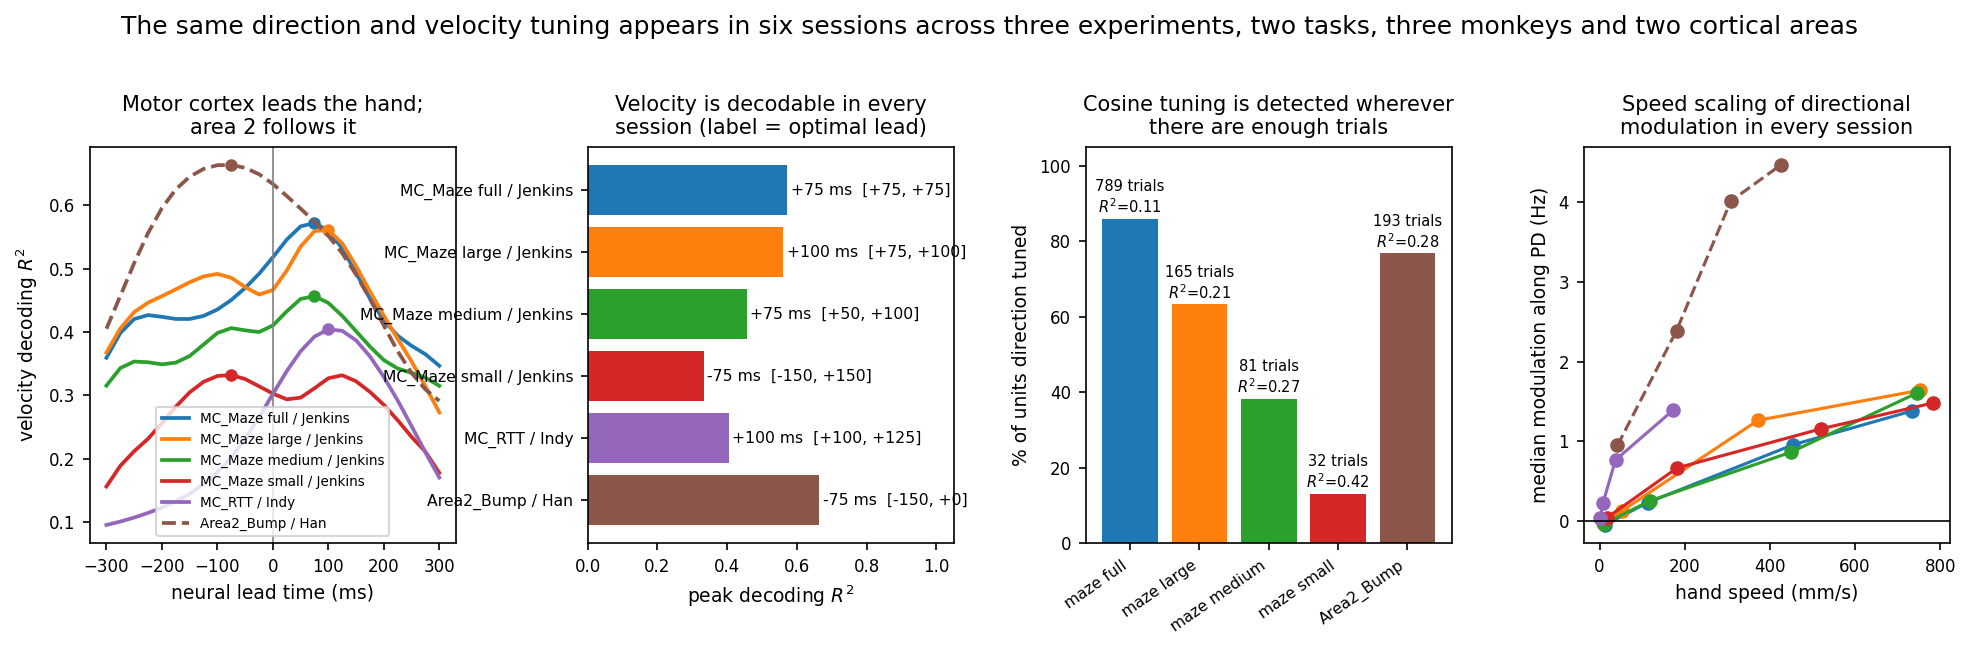

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.4))
fig.subplots_adjust(top=0.76, bottom=0.16, wspace=0.36)
colors = plt.get_cmap("tab10")(np.arange(len(res)))
short = [r["label"].split(" (")[0] + " / " + r["monkey"] for r in res]

ax = axes[0]
for r, c, s_ in zip(res, colors, short):
    ax.plot(LAGS * 1000, r["dec"], color=c, lw=1.8,
            ls="--" if r["area"] == "area2" else "-", label=s_)
    ax.plot(r["lead"] * 1000, r["dec_peak"], "o", color=c, ms=5)
ax.axvline(0, color="0.5", lw=0.8)
ax.set(xlabel="neural lead time (ms)", ylabel="velocity decoding $R^2$",
       title="Motor cortex leads the hand;\narea 2 follows it")
ax.legend(fontsize=6.5, loc="lower center")

ax = axes[1]
y = np.arange(len(res))
ax.barh(y, [r["dec_peak"] for r in res], color=colors)
for i, r in enumerate(res):
    lo, hi = r["lead_folds"].min() * 1000, r["lead_folds"].max() * 1000
    ax.text(r["dec_peak"] + 0.01, i, f"{r['lead']*1000:+.0f} ms  [{lo:+.0f}, {hi:+.0f}]",
            va="center", fontsize=7.5)
ax.set_yticks(y)
ax.set_yticklabels(short, fontsize=7.5)
ax.set(xlabel="peak decoding $R^2$", xlim=(0, 1.05),
       title="Velocity is decodable in every\nsession (label = optimal lead)")
ax.invert_yaxis()

ax = axes[2]
has_dir = [i for i, r in enumerate(res) if not np.isnan(r["dirtuned"])]
ax.bar(np.arange(len(has_dir)), [res[i]["dirtuned"] * 100 for i in has_dir],
       color=[colors[i] for i in has_dir])
for j, i in enumerate(has_dir):
    ax.text(j, res[i]["dirtuned"] * 100 + 1.5,
            f"{res[i]['ntheta']} trials\n$R^2$={res[i]['dir_r2']:.2f}",
            ha="center", fontsize=7)
ax.set_xticks(np.arange(len(has_dir)))
ax.set_xticklabels([short[i].split(" / ")[0].replace("MC_Maze ", "maze ")
                    for i in has_dir], rotation=35, ha="right", fontsize=7.5)
ax.set(ylabel="% of units direction tuned", ylim=(0, 105),
       title="Cosine tuning is detected wherever\nthere are enough trials")

ax = axes[3]
for r, c in zip(res, colors):
    ax.plot(r["centres"], np.nanmedian(r["md"], axis=1), marker="o", color=c,
            ls="--" if r["area"] == "area2" else "-")
ax.axhline(0, color="k", lw=0.8)
ax.set(xlabel="hand speed (mm/s)", ylabel="median modulation along PD (Hz)",
       title="Speed scaling of directional\nmodulation in every session")

fig.suptitle("The same direction and velocity tuning appears in six sessions across "
             "three experiments, two tasks, three monkeys and two cortical areas",
             fontsize=12, y=0.96)
save_show(fig, "fig05_cross_session.png", bbox_inches="tight")

**What figure 5 shows.** Hand velocity is decodable from the population in
all six sessions, with peak R^2 from 0.33 to 0.66, and directional modulation
grows with speed everywhere.  The lead times separate cleanly by area: the
three well-sampled motor cortex maze sessions peak at +75 to +100 ms and the
self-paced M1 session at +100 ms, while area 2 peaks at -75 ms.  Motor cortex
activity precedes the hand; proprioceptive cortex follows it.  The four maze
sessions differ enormously in size (2295 down to 100 trials) yet three of them
agree on the lead to within 25 ms.

Two caveats worth stating plainly.  The smallest maze session (100 trials,
2500 bins) has a flat, double-peaked lag curve, and its per-fold estimates of
the optimal lead span the entire range tested, so its nominally negative lead
should not be read as a real difference from the other Jenkins sessions.  And
the falling fraction of significantly direction-tuned units across the four
maze sessions (86%, 63%, 38%, 13%) tracks the number of barrier-free trials
available (789, 165, 81, 32), which is statistical power rather than a
property of the neurons; the median R^2 among the units that do reach
significance moves the other way, from 0.11 to 0.42.

## Summary

* 130 of 150 motor cortical units in the MC_Maze session are significantly
  cosine tuned for reach direction during movement (permutation p < 0.01),
  with preferred directions spread over the whole circle.
* The directional modulation is speed dependent: across all units its median
  rises from -0.03 Hz in the slowest quartile of hand speeds to 1.34 Hz in the
  fastest (about 3 Hz among the 40 best-fit units), and adding a speed-scaled
  term to a direction-only model improves the cross-validated fit in 123 of
  150 units.
* Firing rate leads hand velocity.  Population decoding peaks at a neural
  lead of 75 to 100 ms in all four motor cortex sessions and in the
  independent M1 random-target session, and at -75 ms in somatosensory area
  2, which is the expected sign reversal for a proprioceptive area.
* A linear readout of 150 simultaneously recorded units recovers hand
  velocity on held-out single trials with R^2 = 0.62 and 0.52 for the two
  components, rising monotonically with the number of units included.
* Direction tuning during the instructed delay is real but does not share the
  movement-epoch preferred direction, and a split-half control rules out
  estimation noise as the explanation.